# Phase 2 Mini Project: Order Delay Intelligence

**Goal**: Predict which orders are likely to be delayed and understand why, using the Brazilian E-Commerce Public Dataset by Olist.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn & XGBoost
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import xgboost as xgb
import shap

# Configure visual settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Audit & EDA

First, we'll load the relevant datasets and merge them.

In [2]:
base_path = r'F:\Datasets and ML\datasets\Brazilian E-Commerce Public Dataset by Olist'

orders = pd.read_csv(f'{base_path}\\olist_orders_dataset.csv')
items = pd.read_csv(f'{base_path}\\olist_order_items_dataset.csv')
products = pd.read_csv(f'{base_path}\\olist_products_dataset.csv')
customers = pd.read_csv(f'{base_path}\\olist_customers_dataset.csv')
payments = pd.read_csv(f'{base_path}\\olist_order_payments_dataset.csv')

print(f'Orders shape: {orders.shape}')
print(f'Items shape: {items.shape}')
print(f'Products shape: {products.shape}')
print(f'Customers shape: {customers.shape}')
print(f'Payments shape: {payments.shape}')

Orders shape: (99441, 8)
Items shape: (112650, 7)
Products shape: (32951, 9)
Customers shape: (99441, 5)
Payments shape: (103886, 5)


### Merge Datasets
We will join these tables on their respective keys to create a consolidated dataset.

In [3]:
# Join Orders and Customers
df = pd.merge(orders, customers, on='customer_id', how='left')

# Join with Items
df = pd.merge(df, items, on='order_id', how='left')

# Join with Products
df = pd.merge(df, products, on='product_id', how='left')

# Aggregate Payments per order and join
payment_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
df = pd.merge(df, payment_agg, on='order_id', how='left')

print(f'Merged dataset shape: {df.shape}')
display(df.head())

Merged dataset shape: (113425, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,28.62


### Handle Missing Values and Date Formatting

In [4]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    
print("Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing Values:
 order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
payment_value                       3
dtype: int64


### Target Variable: `is_delayed`

We define an order as delayed if `order_delivered_customer_date` is strictly greater than `order_estimated_delivery_date`.

Overall Delay Rate: 7.91%


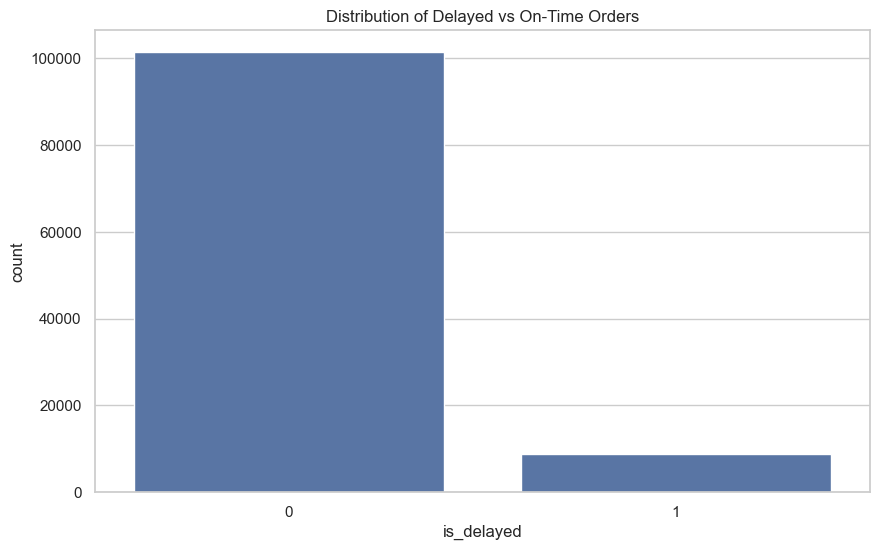

In [5]:
# Filter for delivered orders only
df = df[df['order_status'] == 'delivered'].copy()

# Create target variable
df['is_delayed'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

delay_rate = df['is_delayed'].mean()
print(f'Overall Delay Rate: {delay_rate:.2%}')

sns.countplot(data=df, x='is_delayed')
plt.title('Distribution of Delayed vs On-Time Orders')
plt.show()

### Delay Magnitude

The business also wants to understand *how large* the delay might be for orders that miss their estimated delivery date.

Average delay for delayed orders: 8.7 days
Median delay for delayed orders: 5.0 days
90th percentile of delay: 20.0 days


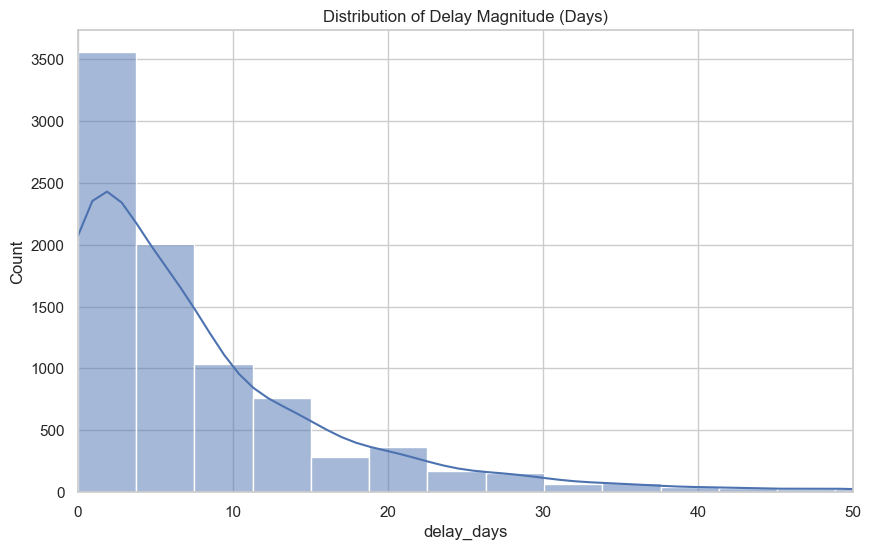

In [6]:
# Calculate delay in days for delayed orders
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

delayed_orders = df[df['is_delayed'] == 1]

print(f"Average delay for delayed orders: {delayed_orders['delay_days'].mean():.1f} days")
print(f"Median delay for delayed orders: {delayed_orders['delay_days'].median():.1f} days")
print(f"90th percentile of delay: {delayed_orders['delay_days'].quantile(0.90):.1f} days")

sns.histplot(data=delayed_orders, x='delay_days', bins=50, kde=True)
plt.title('Distribution of Delay Magnitude (Days)')
plt.xlim(0, 50)
plt.show()

## 2. SQL Practice

We will dump our dataset into a local SQLite database to practice extracting insights using SQL.

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('orders_data', conn, index=False, if_exists='replace')

# Query 1: Delay rate by state
query_state = '''
SELECT customer_state, 
       COUNT(order_id) as total_orders,
       SUM(is_delayed) as delayed_orders,
       ROUND(CAST(SUM(is_delayed) AS FLOAT) / COUNT(order_id) * 100, 2) as delay_rate_percent
FROM orders_data
GROUP BY customer_state
HAVING total_orders > 100
ORDER BY delay_rate_percent DESC
LIMIT 10
'''
print("Top 10 States by Delay Rate:")
display(pd.read_sql(query_state, conn))

Top 10 States by Delay Rate:


,customer_state,total_orders,delayed_orders,delay_rate_percent
0,AL,427,103,24.12
1,MA,800,163,20.38
2,SE,375,61,16.27
3,PI,523,81,15.49
4,CE,1426,218,15.29
5,BA,3683,504,13.68
6,RJ,14143,1835,12.97
7,PA,1054,131,12.43
8,TO,310,38,12.26
9,ES,2225,272,12.22


In [8]:
# Query 2: Delay rate by product category
query_category = '''
SELECT product_category_name, 
       COUNT(order_id) as total_orders,
       ROUND(CAST(SUM(is_delayed) AS FLOAT) / COUNT(order_id) * 100, 2) as delay_rate_percent
FROM orders_data
WHERE product_category_name IS NOT NULL
GROUP BY product_category_name
HAVING total_orders > 50
ORDER BY delay_rate_percent DESC
LIMIT 10
'''
print("\nTop 10 Product Categories by Delay Rate:")
display(pd.read_sql(query_category, conn))


Top 10 Product Categories by Delay Rate:


,product_category_name,total_orders,delay_rate_percent
0,audio,362,12.71
1,fashion_underwear_e_moda_praia,127,12.60
2,artigos_de_natal,150,12.00
3,livros_tecnicos,263,11.03
4,casa_conforto,429,10.26
5,construcao_ferramentas_iluminacao,301,9.97
6,alimentos,499,9.82
7,eletronicos,2729,9.75
8,beleza_saude,9465,9.05
9,moveis_escritorio,1668,8.93


## 3. Feature Engineering & Preprocessing

We need to create useful features that models can learn from, such as the estimated time to delivery, freight value, order price, and customer state.

In [9]:
# Feature Engineering
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['freight_ratio'] = df['freight_value'] / df['payment_value'].replace(0, 1) # Avoid division by zero

# Select features
features = ['payment_value', 'freight_value', 'price', 'product_weight_g', 
            'estimated_delivery_days', 'customer_state', 'freight_ratio']

model_df = df.dropna(subset=features + ['is_delayed']).copy()

X = model_df[features]
y = model_df['is_delayed']

print(f"Shape of X: {X.shape}")

Shape of X: (110176, 7)


In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing pipelines
numeric_features = ['payment_value', 'freight_value', 'price', 'product_weight_g', 'estimated_delivery_days', 'freight_ratio']
categorical_features = ['customer_state']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

## 4. Baseline Models
Let's train Logistic Regression and Random Forest as baselines.

In [11]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
print("Logistic Regression AUC:", roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1]))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr))

Logistic Regression AUC: 0.6849554657895187

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       0.95      0.65      0.77     20294
           1       0.13      0.63      0.22      1742

    accuracy                           0.65     22036
   macro avg       0.54      0.64      0.50     22036
weighted avg       0.89      0.65      0.73     22036



In [12]:
# Random Forest Pipeline (limited depth for speed initially)
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print("Random Forest AUC:", roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:, 1]))
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

Random Forest AUC: 0.7155565059299932

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.95      0.75      0.84     20294
           1       0.16      0.56      0.25      1742

    accuracy                           0.74     22036
   macro avg       0.56      0.66      0.55     22036
weighted avg       0.89      0.74      0.79     22036



## 5. XGBoost Model & Tuning
Now we'll use XGBoost which often provides strong performance on tabular data.

In [13]:
import xgboost as xgb

# We'll use scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', 
                                     scale_pos_weight=scale_pos_weight, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
print("XGBoost AUC:", roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:, 1]))
print("\nClassification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))

XGBoost AUC: 0.7309231110935607

Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.95      0.75      0.84     20294
           1       0.17      0.57      0.26      1742

    accuracy                           0.74     22036
   macro avg       0.56      0.66      0.55     22036
weighted avg       0.89      0.74      0.80     22036



### Cross-Validation

To ensure our model's performance is stable, we evaluate it using 5-fold cross-validation on the training set.

In [14]:
# Perform 5-fold Cross Validation for ROC-AUC
cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost CV ROC-AUC Scores: {cv_scores}")
print(f"Average CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

XGBoost CV ROC-AUC Scores: [0.72798479 0.71990631 0.73357659 0.73220851 0.73382757]
Average CV ROC-AUC: 0.7295 (+/- 0.0105)


## 6. Model Interpretation (SHAP)
Understanding which features drive the prediction of delay.

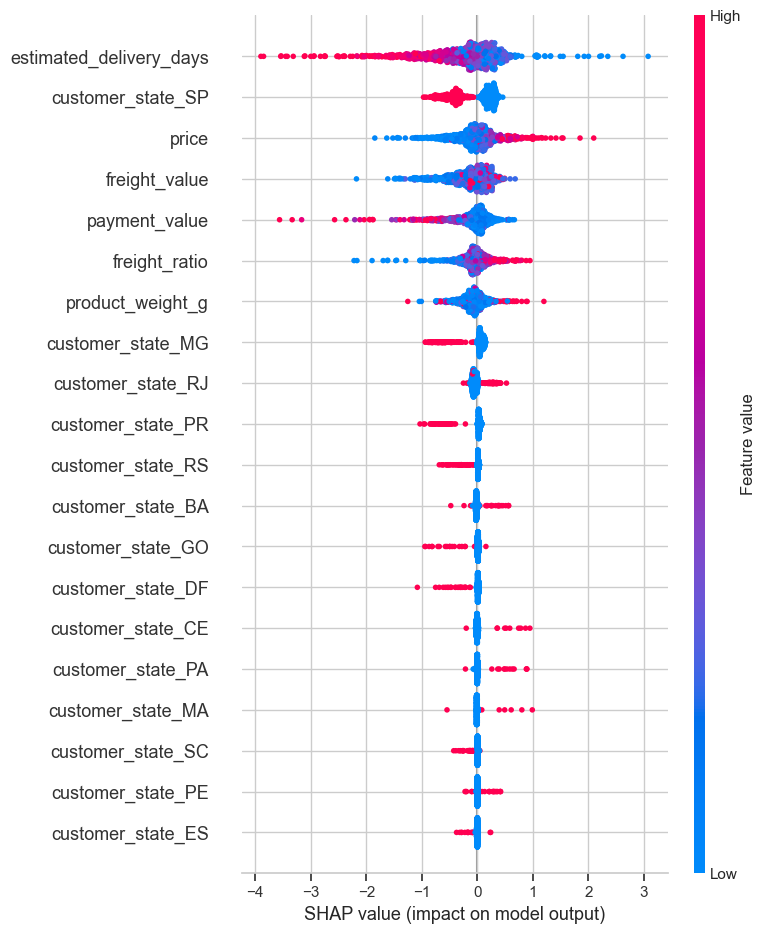

In [15]:
# Extract preprocessed data and model
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
model = xgb_pipeline.named_steps['classifier']

# Get feature names after one-hot encoding
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

# Convert back to DataFrame for SHAP
X_train_sh = pd.DataFrame(X_train_preprocessed, columns=all_features)
X_test_sh = pd.DataFrame(X_test_preprocessed, columns=all_features)

# Create SHAP Explainer
# Using a sample to speed up SHAP values calculation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sh.sample(1000, random_state=42))

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_sh.sample(1000, random_state=42))